Class RandomWalk represents a grid of size $1\times N$. 

For each vertex $x$ of the grid we generate a uniform random variable on the interval $[0.1,0.9]$ -- $w[x]$. 

For each vertex we can pick two actions $a[x]\in \{0,1\}$. 

If action $a[x]=0$ is chosen then the random walk moves to the right with probability $\frac{w[x+1]}{w[x-1]+w[x+1]}$ and to the left with probability $\frac{w[x-1]}{w[x-1]+w[x+1]}$.

If action $a[x]=1$ is chosen then the random walk moves to the right with probability $\frac{w[x-1]}{w[x-1]+w[x+1]}$ and to the left with probability $\frac{w[x+1]}{w[x-1]+w[x+1]}$. 

$N$ -- size of grid 
$x$ -- initial position of the random walk. If not given then a random value on $[1,N-1]$ is assigned

Import required libraries. 

Class StateActionReward describes the state space of Markov Decision Process with states, actions and rewards. 

In [821]:
import numpy as np 
import math 
import matplotlib.pyplot as plt
import random 
import copy 
from collections import namedtuple



class StateActionReward:
    def __init__(self, s, a, r):

        self.s = s  # State
        self.a = a  # Action
        self.r = r  # Reward

    
    def copy(self):
        
        return StateActionReward(copy.copy(self.s),self.a,self.r)    

    def __repr__(self):
        return f"StateActionReward(s={self.s}, a={self.a}, r={self.r})"


class RandomWalk is a parent class of one-dimensional random walk and two-dimensional random walk. 
It generates a full episode of the Markov Decision Process in generate_episode.
It also lists the functions needed to generate this full episode. 


In [822]:


class RandomWalk:

    def is_state_terminal(self, p):
        """
            Verifies if the state is final for the episode 
            This function is to be extended by the child classes
        """
        pass

    def next_step(self,p):
        """
            Generates the next state of the episode 
            This function is to be extended by the child classes
            :param p: state, action, reward
            :return: next state, action, reward
        """
        

        pass 

    def get_action(self,s):
        """
            Gets action corresponding to the state. The actions is decided by a policy.  
            This function is to be extended by the child classes
            :param s: state
            :return: action 
        """
        pass

    def get_reward(self, p_prev : StateActionReward, p: StateActionReward):
        """
            Generates a reward
            This function is to be extended by the child classes
            
            :param p_prev: previous state,action, rewards
            :param p_prev: current state,action, rewards
            :return: reward
        """
        pass 

    def generate_episode(self,p: StateActionReward):

        """
            Generates all states, action, rewards in an episode 
            This function is to be extended by the child classes

            :param p: Initial state, action
            :return: the full episode
        """
        p_new = p.copy()
        s = [p]
        while not self.is_state_terminal(p_new):
            p_new = self.next_step(p_new).copy()
            p_new.a = self.get_action(p_new.s) 
            s.append(p_new) 
        return s 

Class Random Walk1D specifies RandomWalk in one-dimensional case 

In [823]:
class RandomWalk1D(RandomWalk):

    def __init__(self, N): 
        self.N = N
        self.w = np.ones(N)
        #self.w = np.random.uniform(low=0.1, high=0.9, size=N)
      
        self.pi = np.zeros(N, dtype=int) # policy 
        self.l = np.zeros(N, dtype=int)  # number of times Q(x,a) was updated 
        self.Q = np.zeros((self.N, 2))   # Q(state[0], state[1], action) action value function 
        self.V = [[] for _ in range(N)]  # value function 
        
        print("Weights of points")
        print(self.w)

    def update_policy(self, s):

        """
            updates policy for state s using the greedy approach maximising Q(s,a)
        """

        
        if self.Q[s,0]> self.Q[s,1]:
                self.pi[s] = 0 
        else:
                self.pi[s] = 1 

    def evaluate_policy(self):

        """
            updates policy for all states
        """

        for s in range(self.N):
            self.update_policy(s)

    def get_action(self,s):
        """
            Gets action corresponding to the state. The actions is decided by a policy.  
            :param s: state
            :return: action 
        """
        return self.pi[s]

    def is_state_terminal(self,p):
        """
            Verifies if the state is final for the episode 
            :param p: state,action, reward
            :return: true if the MDP terminates at this state
        """
        
        return p.s == 0 or p.s == self.N-1 
    
    def random_start(self):
        """
            generates random starting point 
        """
        return StateActionReward(s=np.random.randint(0, self.N), a= np.random.randint(0, 2), r=0)

    def get_reward(self, p_prev: StateActionReward, p: StateActionReward):
        """
            Generates a reward
            
            :param p_prev: previous state,action, rewards
            :param p_prev: current state,action, rewards
            :return: reward
        """
        return 1 if p.s == self.N-1 else 0 

    def get_Q(self, p):

        """
            :param p: state,a action, reward
            :return: Q(state, action)
        """
        return self.Q[p.s,p.a]
    
    def get_l(self,p):

        """
            :param p: state,a action, reward
            :return: number of times state,action has been updated  
        """

        return self.l[p.s]
    
    def set_Q(self, p, Q):

        """
            updates the value of Q(state, action) by new Q
            adds 1 to number of updates l
        """

        self.Q[p.s,p.a] = Q
        self.l[p.s]+=1
        self.V[p.s].append(max(self.Q[p.s,0],self.Q[p.s,1]))

    def get_V_current(self):
        V_current = np.zeros(self.N)
        for i in range(self.N):
                V_current[i] = max(self.Q[i,0],self.Q[i,1])   
        return V_current        
    

    def next_step(self,  p):
        """
        If a=1 then it jumps to the right with probability w[x+1]/(w[x-1]+w[x+1]) and left otherwise. 
        If a=0 then it jumps to the right with probability w[x-1]/(w[x-1]+w[x+1]) and left otherwise. 

        :param p: current state, action, reward

        :return: next state, action reward 
        
        """
        total = self.w[p.s+1]+self.w[p.s-1]
        if p.a == 1:
            prob = self.w[p.s+1]/total
        else:
            prob = self.w[p.s-1]/total 
        
        p_new = p.copy() 
        if prob>np.random.rand():
            p_new.s=p_new.s+1
        else:
            p_new.s=p_new.s-1    
       
        p_new.r = self.get_reward(p,p_new)
        
        return p_new 
     
    


Class describing two-dimensional random walk. 
Functions are the same as in one-dimensional case. The main change is the change in dimensions 

In [824]:
class RandomWalk2D(RandomWalk):

    # in StationActionReward state s is an array of two coordinates [s[0],s[1]]
    
    def __init__(self, N): 
        self.N = N
        self.pi = np.zeros((self.N, self.N), dtype=int) # policy 
        self.l = np.zeros((self.N, self.N), dtype=int)  # number of times Q(x,a) was updated 
        self.Q = np.zeros((self.N, self.N, 2)) # Q(state[0], state[1], action)
        #self.w = np.ones((self.N, self.N))  # weights of states 
        self.w = np.random.rand(self.N, self.N)
        print("Weights are give by")
        print(self.w)
        
        self.V = [[[] for _ in range(N)] for _ in range(N)]
        

    def get_Q(self, p):
        return self.Q[p.s[0],p.s[1],p.a]
    
    def get_l(self,p):
        return self.l[p.s[0],p.s[1]]
    
    def set_Q(self, p, Q):
        self.Q[p.s[0],p.s[1],p.a] = Q
        self.l[p.s[0],p.s[1]]+=1
        self.V[p.s[0]][p.s[1]].append(max(self.Q[p.s[0],p.s[1],0],self.Q[p.s[0],p.s[1],1]))

    def get_V_current(self):
        V_current = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N): 
                V_current[i,j] = max(self.Q[i,j,0],self.Q[i,j,1])   
        return V_current        

        

    def evaluate_policy(self):

        for i in range(self.N):
            for j in range(self.N):
                if self.Q[i,j,0]> self.Q[i,j,1]:
                    self.pi[i,j] = 0 
                else:
                    self.pi[i,j] = 1    

    def get_action(self, s):
        return self.pi[s[0],s[1]]         
        
    def is_state_terminal(self, p: StateActionReward):
        return p.s[0] == 0 or p.s[0] == self.N-1 or p.s[1] == 0 or p.s[1] == self.N-1
    
    def random_start(self):
        p = StateActionReward(s=[np.random.randint(1, self.N-1), np.random.randint(1, self.N-1)], a= np.random.randint(0, 2), r=0)
        return p
    

    def get_reward(self, p_prev : StateActionReward, p: StateActionReward):
        return 1 if p.s[0] == self.N-1 else 0 

    def next_step(self,  p: StateActionReward):
        """
        
        :param a: action with possible values 0 or 1 

        return: state and reward with empty action 
        
        """
        
        total = self.w[p.s[0]+1,p.s[1]]+self.w[p.s[0]-1,p.s[1]]+self.w[p.s[0],p.s[1]+1]+self.w[p.s[0],p.s[1]-1]
        if p.a == 1:
            right = self.w[p.s[0]+1,p.s[1]]/total
            left = self.w[p.s[0]-1,p.s[1]]/total
            up = self.w[p.s[0],p.s[1]+1]/total
            down  = self.w[p.s[0],p.s[1]-1]/total
        else:
            left = self.w[p.s[0]+1,p.s[1]]/total
            right = self.w[p.s[0]-1,p.s[1]]/total
            down = self.w[p.s[0],p.s[1]+1]/total
            up = self.w[p.s[0],p.s[1]-1]/total
        
        
        v = random.choices([1,2,3,4],[left,right,down, up])
        u = v[0]
        p_new = p.copy()
        if u==1:
            p_new.s[0]-=1
        elif u==2:
            p_new.s[0]+=1
        elif u==3:   
            p_new.s[1]-=1
        else: 
            p_new.s[1]+=1  
        p_new.r = self.get_reward(p,p_new)
        
        return p_new 
     
    


class MC that applied Monte-Carlo for policy evaluation. 
It requires certain function to be prepared in class RandomWalk

In [825]:
class MC:
    
    def __init__(self, rw, M,beta=1):

        self.rw = rw 
        self.M = M
        self.N = rw.N
        self.beta = beta 
         
    
    
    def run(self):
    
        for i in range(self.M): 
            self.rw.evaluate_policy()
            p = self.rw.random_start()
            episode = self.rw.generate_episode(p)
            T = len(episode)
            g = 0
            for j in range(T-2, -1, -1):
                e = episode[j]
                g=self.beta*g+episode[j+1].r
                Q = self.rw.get_Q(e)
                Q+= (g-self.rw.get_Q(e))/(1+self.rw.get_l(e))
                self.rw.set_Q(e,Q)
                
        

Class SARSA for testing SARSA. 
It requires certain function to be prepared in class RandomWalk

In [826]:
class SARSA:
    
    def __init__(self, rw, M,alpha, beta=1):

        self.rw = rw 
        self.M = M
        self.N = rw.N
        self.alpha = alpha 
        self.beta = beta 
        
        
    def alpha_t(self, l, fixed):
        
        return self.alpha  if fixed else min(0.5,self.alpha/(1+l))
    

    

    def run(self, fixed):
        
        for i in range(self.M): 
            p = self.rw.random_start()
            while not self.rw.is_state_terminal(p):
                p_new = self.rw.next_step(p).copy()
                Q = self.rw.get_Q(p)
                Q_new = self.rw.get_Q(p_new)
                Q+= self.alpha_t(self.rw.get_l(p),fixed)*(p_new.r+self.beta*Q_new-Q)
                self.rw.set_Q(p,Q)
                p = p_new

        

Weights of points
[1. 1. 1. 1. 1. 1.]
Monte-Carlo: Value function for 1D case
[0.         0.20161645 0.40066205 0.6000171  0.80078615 0.        ]
Weights are give by
[[0.73214139 0.02098133 0.02800076 0.90436133 0.52720363 0.44674623]
 [0.51192952 0.09605165 0.79578246 0.74509441 0.97169606 0.541476  ]
 [0.2802199  0.59744043 0.99482916 0.57266806 0.37190185 0.40108238]
 [0.41384191 0.86781959 0.88293617 0.79521439 0.99077368 0.45785829]
 [0.23227508 0.79504828 0.72900376 0.25616551 0.17978865 0.6990455 ]
 [0.9191996  0.21501402 0.20092253 0.47279189 0.19313212 0.1985954 ]]
MC: Value function for 2D case
[[0.         0.         0.         0.         0.         0.        ]
 [0.         0.10140221 0.12240286 0.06926121 0.04221254 0.        ]
 [0.         0.16135917 0.17082269 0.15047364 0.10526019 0.        ]
 [0.         0.21315864 0.23756677 0.22185135 0.18344227 0.        ]
 [0.         0.33171701 0.37622225 0.47643162 0.63520672 0.        ]
 [0.         0.         0.         0.      

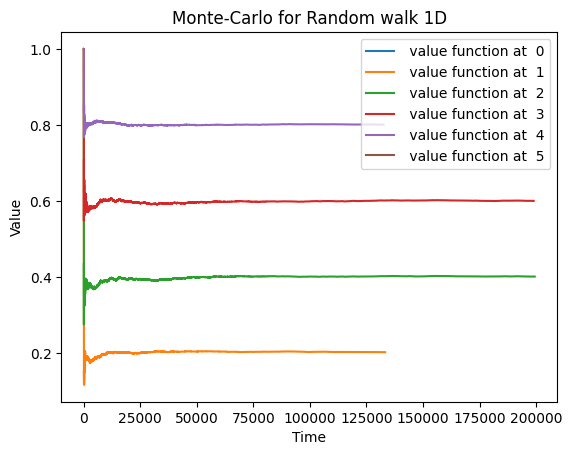

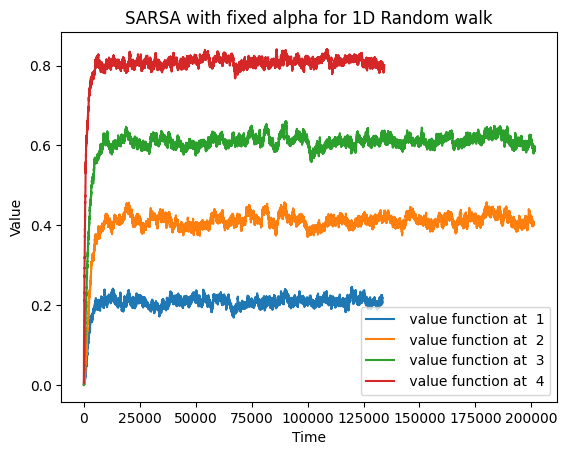

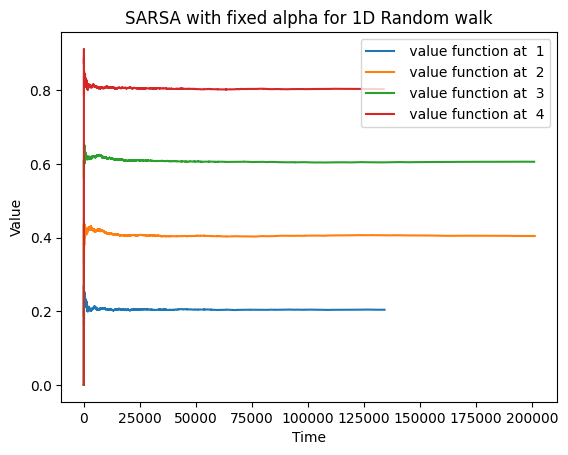

In [827]:
def main():

    beta = 1
    alpha = 0.005
    M = 200000
    N = 6 
    
    #### Monte-Carlo for 1 - dimensional random walk 

    
    rw_1D = RandomWalk1D(N)
    mc_1D = MC(rw_1D,M,beta)
    mc_1D.run()
    
    plt.figure(1)
    for x in range(N):
        plt.plot(mc_1D.rw.V[x], label=" value function at  "+str(x))
        
    print("Monte-Carlo: Value function for 1D case")
    print(rw_1D.get_V_current())
    

    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Monte-Carlo for Random walk 1D')
    plt.legend()

    
    #### Monte-Carlo for 2 - dimensional random walk 

    rw_2D = RandomWalk2D(N)
    mc_2D = MC(rw_2D,M,beta)
    mc_2D.run()
    print("MC: Value function for 2D case")
    print(rw_2D.get_V_current())
    
    
    #### SARSA with fixed alpha

    rw_1D_sarsa = RandomWalk1D(N)
    sarsa = SARSA(rw_1D_sarsa,M,alpha,beta)
    sarsa.run(True)

    plt.figure(3)
    for x in range(1,N-1):
        plt.plot(rw_1D_sarsa.V[x], label=" value function at  "+str(x))

    print("SARSA with fixed alpha: value function")    
    print(rw_1D_sarsa.get_V_current())

    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('SARSA with fixed alpha for 1D Random walk')
    plt.legend()

    #### SARSA with varying alpha

    alpha = 4 
    rw_1D_sarsa_alpha = RandomWalk1D(N)
    sarsa_alpha = SARSA(rw_1D_sarsa_alpha,M,alpha,beta)
    sarsa_alpha.run(False)

    plt.figure(4)
    for x in range(1,N-1):
        plt.plot(rw_1D_sarsa_alpha.V[x], label=" value function at  "+str(x))

    print("SARSA with varying alpha: value function")    
    print(rw_1D_sarsa_alpha.get_V_current())

    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('SARSA with fixed alpha for 1D Random walk')
    plt.legend()
    

    

if __name__ == "__main__":
    # Call the main function
    main()